In [1]:
import sys
sys.path.append('photon')

In [2]:
import torch
from scipy import ndimage
import torch.nn.functional as F
from data import BeamData, Plan
from models import BeamNet, LaplacianSmoothness2DLoss
import torch.nn as nn
from pathlib import Path
import numpy as np

In [3]:
data_dir = Path("/workspace/DoseRAD2026Dev/data/DoseRAD2026/photon/training")

np.random.seed(1234)
pt_list = [f.name for f in data_dir.iterdir() if f.is_dir()]
np.random.shuffle(pt_list)

pt_tr = pt_list[:50]
pt_vl = pt_list[50:60]
pt_ts = pt_list[60:]

In [4]:
for pt in pt_tr:
    pat_dir = data_dir / pt
    plan = Plan(
        img_file_path=rf"{pat_dir}/image/ct.mha",
        info_json_path=rf"{pat_dir}/{pt}.json",
        dose_dir=rf"{pat_dir}/dose",
    )
    print(pt)

    break

State set to 0
1ABB143


In [5]:
d = BeamData(plan, pad_voxels=(0,40,0))

Reading dose files:   7%|▋         | 13/180 [00:00<00:05, 28.93it/s]

Reading dose files: 100%|██████████| 180/180 [00:04<00:00, 36.31it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (180, 129, 252, 276)
Data type: float16
Padded using (0, 0, 40, 40, 0, 0)


Rotating dose & img: 100%|██████████| 6/6 [00:20<00:00,  3.35s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 6/6 [00:06<00:00,  1.15s/it]


In [6]:
import matplotlib.pyplot as plt

In [7]:
# How many touches the top and bottom border, i.e. needs padding
mask = d.img_rot>-1024
bev_m = (mask * d.bev)
(bev_m[10][:, 0].sum(1) + bev_m[10][:, -1].sum(1)).bool().sum()

tensor(0)

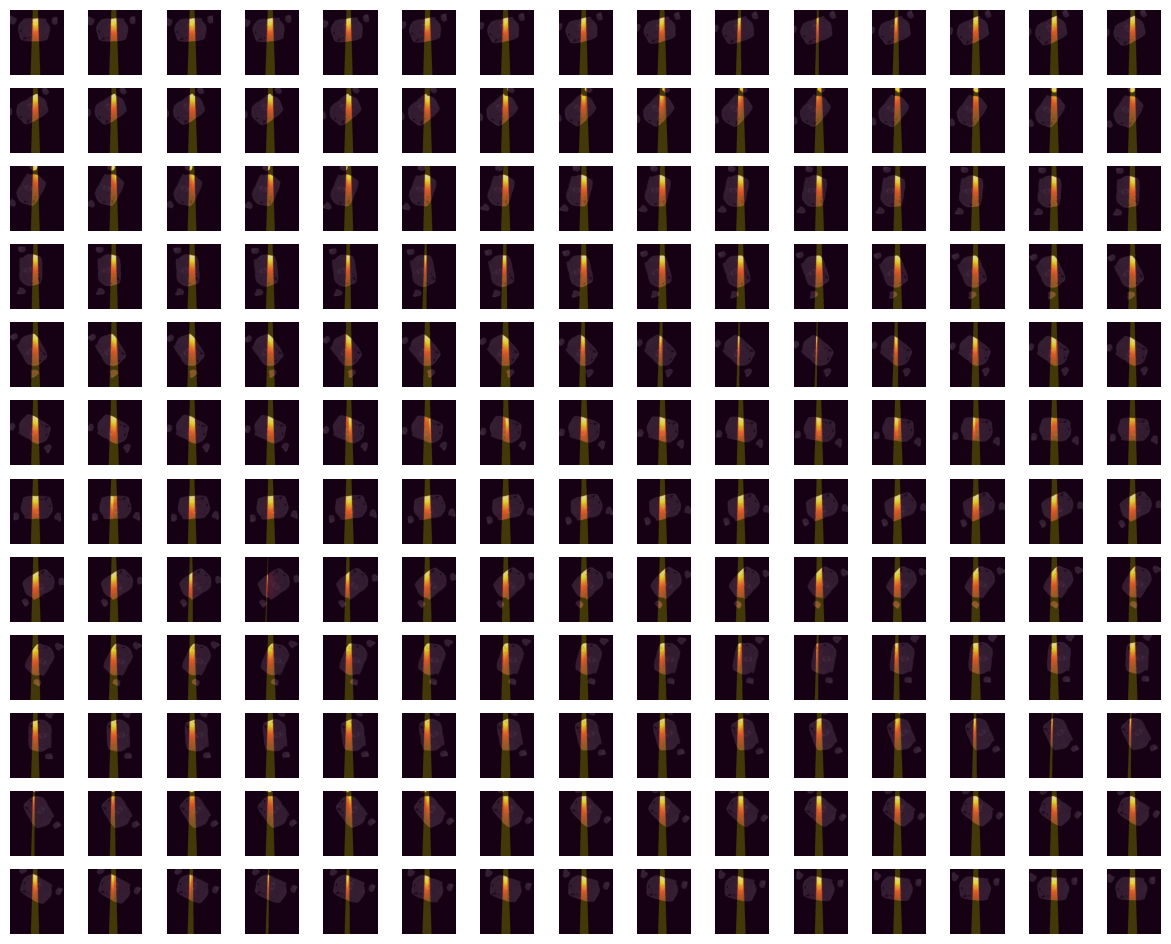

In [8]:
fig, ax = plt.subplots(12, 15, figsize=(15,12))
ax = ax.ravel()
for i in range(180):
    ax[i].imshow(d.img_rot[i][76], cmap='gray')
    ax[i].imshow(d.bev[i][76], alpha=0.5)
    ax[i].imshow(d.dose[i][76], cmap='hot', alpha=0.5)
    ax[i].axis('off')

In [10]:
self = d
idx = 0
img = self.img_rot[idx]
bev = self.bev[idx]
mask = img > -1024
dose = self.dose[idx]
depth = self.depth[idx]
wed = self.wed[idx]

loc = self.bbox_loc

img, bev, mask, loc, dose, depth, wed = (
    img[loc], bev[loc], mask[loc], loc, dose[loc], depth[loc], wed[loc]
)

In [9]:
img, bev, mask, loc, dose, depth, wed = d[0]

AttributeError: 'BeamData' object has no attribute 'loc'

In [11]:
mask.shape

torch.Size([129, 290, 276])

In [12]:
img.shape

torch.Size([129, 290, 276])

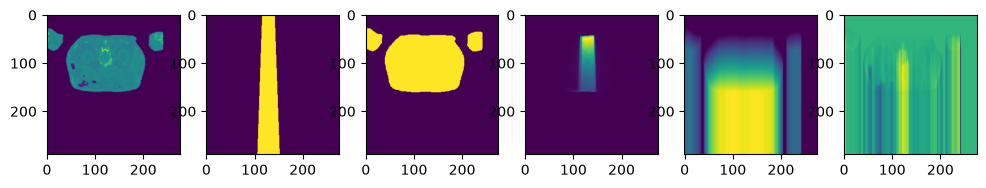

In [13]:
fig, ax = plt.subplots(1, 6, figsize=(12,2))
ax[0].imshow(img[76])
ax[1].imshow(bev[76])
ax[2].imshow(mask[76])
ax[3].imshow(dose[76])
ax[4].imshow(depth[76])
ax[5].imshow(wed[76])

In [14]:
data = dict(
    img=img, bev=img, mask=mask, dose=dose, depth=depth, wed=wed
)

(np.float64(-0.5), np.float64(275.5), np.float64(331.5), np.float64(-0.5))

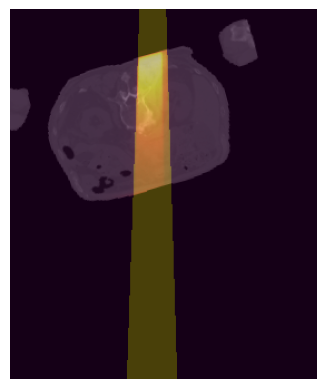

In [9]:
plt.imshow(d.img_rot[8][76], cmap='gray')
plt.imshow(d.bev[8][76], alpha=0.4)
plt.imshow(d.dose[8][76], cmap='hot', alpha=0.3)
plt.axis('off')